In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('data/home_prices.csv')
df.head()

,area_sqr_ft,bedrooms,color,price_lakhs
0,3774,2,Red,216
1,1460,3,Gray,88
2,1894,4,Gray,147
3,1730,2,Blue,84
4,1695,1,Blue,77


# Feature selection using Correlation

In [3]:
df.area_sqr_ft.corr(df.price_lakhs)

np.float64(0.9453650260417832)

In [5]:
df_encoded=pd.get_dummies(df,columns=['color'],drop_first=True,dtype=int)
df_encoded.head()

,area_sqr_ft,bedrooms,price_lakhs,color_Gray,color_Green,color_Red,color_White,color_Yellow
0,3774,2,216,0,0,1,0,0
1,1460,3,88,1,0,0,0,0
2,1894,4,147,1,0,0,0,0
3,1730,2,84,0,0,0,0,0
4,1695,1,77,0,0,0,0,0


In [7]:
cm=df_encoded.corr()
cm

,area_sqr_ft,bedrooms,price_lakhs,color_Gray,color_Green,color_Red,color_White,color_Yellow
area_sqr_ft,1.000000,0.185810,0.945365,-0.068944,-0.032012,0.059055,0.063827,-0.037819
bedrooms,0.185810,1.000000,0.439445,0.040882,-0.120207,-0.004177,-0.023676,0.015286
price_lakhs,0.945365,0.439445,1.000000,-0.040565,-0.041959,0.045803,0.051122,-0.046673
color_Gray,-0.068944,0.040882,-0.040565,1.000000,-0.214409,-0.230990,-0.205931,-0.217205
color_Green,-0.032012,-0.120207,-0.041959,-0.214409,1.000000,-0.190117,-0.169493,-0.178771
color_Red,0.059055,-0.004177,0.045803,-0.230990,-0.190117,1.000000,-0.182600,-0.192596
color_White,0.063827,-0.023676,0.051122,-0.205931,-0.169493,-0.182600,1.000000,-0.171703
color_Yellow,-0.037819,0.015286,-0.046673,-0.217205,-0.178771,-0.192596,-0.171703,1.000000


In [ ]:
round(abs(cm.price_lakhs),2)# > 0.2 features are not important refering to price_lakhs

area_sqr_ft     0.95
bedrooms        0.44
price_lakhs     1.00
color_Gray      0.04
color_Green     0.04
color_Red       0.05
color_White     0.05
color_Yellow    0.05
Name: price_lakhs, dtype: float64

In [21]:
cm[cm.price_lakhs>.2].index # Correlation threshold is set to 0.2

Index(['area_sqr_ft', 'bedrooms', 'price_lakhs'], dtype='str')

In [15]:
selected_features=cm[cm.price_lakhs>.2].index.drop('price_lakhs')

In [ ]:
selected_features

Index(['area_sqr_ft', 'bedrooms'], dtype='str')

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

x=df[selected_features]
y=df.price_lakhs

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')

Mean Squared Error: 76.63332198278805
R2 Score: 0.9689466488379601


## Scenorios where not to use correlation for feature selection:  
1. Non-Linear relation  
2. presence of outliers  
3. many categorical variables in data frame  
4. correlation VS causation

# Variance Inflation Factor(VIF)

In [23]:
df=pd.read_csv('data/salaries.csv')
df.head()

,Years of Experience,Education Level,Age,Location Factor,Salary
0,29,1,49,7,124204
1,27,3,45,4,125948
2,20,4,41,8,116078
3,14,4,37,5,106486
4,20,3,42,7,113297


In [58]:
x=df.drop('Salary',axis=1)
y=df.Salary

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
model.coef_# here the 3ed feature is negative

array([2109.51761869, 5060.61877537, -120.2791406 , 1495.70225789])

In [46]:
model.intercept_

np.float64(52519.183036886585)

In [59]:
print(x_test[:1],y_test[:1])

     Years of Experience  Education Level  Age  Location Factor
521                   15                3   37                5 521    97186
Name: Salary, dtype: int64


In [60]:
model.intercept_ + model.coef_[0]*15 + model.coef_[1]*3 + model.coef_[2]*37 + model.coef_[3]*5

np.float64(102371.98673051776)

In [24]:
df['Location Factor'].value_counts()

Location Factor
1     118
3     110
5     107
10    107
8     100
6      96
7      94
4      94
9      91
2      83
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Salary'>

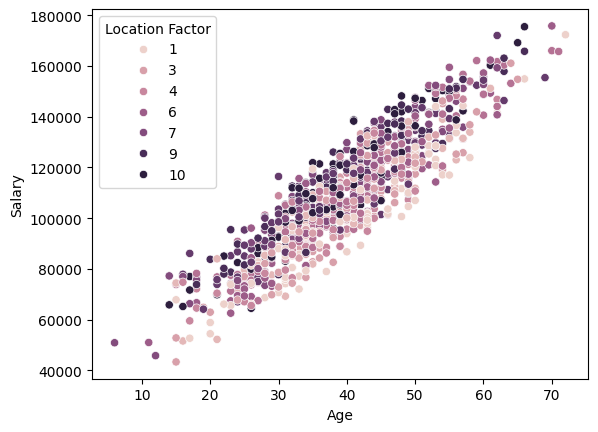

In [25]:
import seaborn as sns

sns.scatterplot(df,x='Age',y='Salary',hue='Location Factor')

<Axes: >

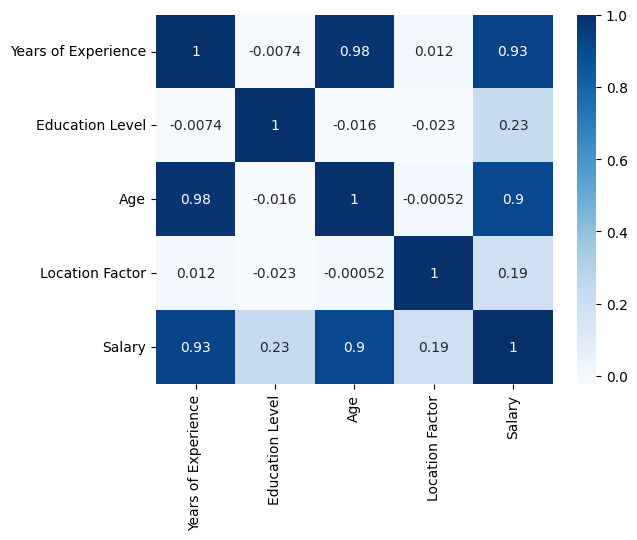

In [34]:
cm=df.corr()

sns.heatmap(cm,annot=True,cmap='Blues')

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif=pd.DataFrame()
    vif["feature"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

In [39]:
x=df.drop('Salary',axis=1)

calculate_vif(x)

,feature,VIF
0,Years of Experience,27.789897
1,Education Level,1.002909
2,Age,27.791848
3,Location Factor,1.004877


In [40]:
# droping one features which is >10
calculate_vif(x.drop('Age',axis=1))

,feature,VIF
0,Years of Experience,1.000189
1,Education Level,1.000584
2,Location Factor,1.000669


In [61]:
x_train,x_test,y_train,y_test=train_test_split(x.drop('Age',axis=1),df.Salary,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9592314656682582

In [62]:
model.coef_

array([1994.10983096, 5070.62814345, 1500.8453815 ])

In [63]:
model.intercept_

np.float64(49934.24068274489)

In [64]:
x_test[:1]

,Years of Experience,Education Level,Location Factor
521,15,3,5


In [65]:
y_test[:1]

521    97186
Name: Salary, dtype: int64

In [68]:
model.intercept_ + model.coef_[0]*15 + model.coef_[1]*3 + model.coef_[2]*5

np.float64(102561.99948499899)

In [69]:
model.score(x_test,y_test)

0.9592314656682582